In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Load Dataset
df = pd.read_csv("final_dataset.csv")
df.head()

,Unnamed: 0,beds,baths,size,zip_code,price
0,0,3,2.5,2590.0,98144,795000.0
1,1,4,2.0,2240.0,98106,915000.0
2,2,4,3.0,2040.0,98107,950000.0
3,3,4,3.0,3800.0,98199,1950000.0
4,4,2,2.0,1042.0,98102,950000.0


In [11]:
# Select Features
X = df[["beds", "baths", "size"]]

# Scale Data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [12]:
# Elbow Method
inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

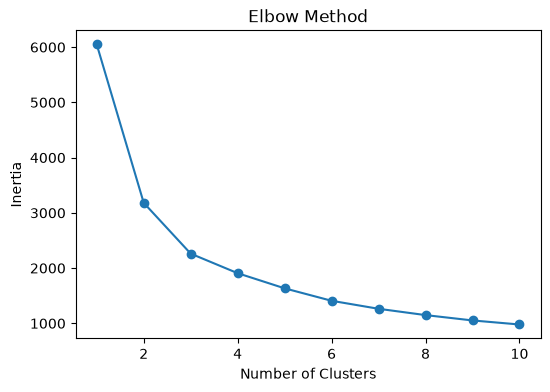

In [13]:
plt.figure(figsize=(6,4))
plt.plot(range(1,11), inertia, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

In [14]:
# Final Model (Change k based on elbow graph)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)

In [15]:
# Add Cluster Column
df["Cluster"] = labels

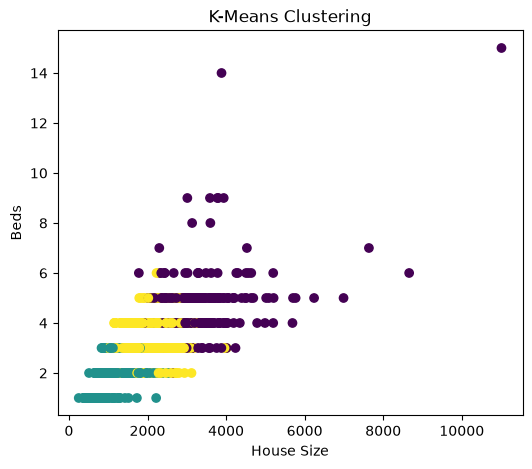

   Unnamed: 0  beds  baths    size  zip_code      price  Cluster
0           0     3    2.5  2590.0     98144   795000.0        2
1           1     4    2.0  2240.0     98106   915000.0        2
2           2     4    3.0  2040.0     98107   950000.0        2
3           3     4    3.0  3800.0     98199  1950000.0        0
4           4     2    2.0  1042.0     98102   950000.0        1


In [16]:
# Scatter Plot
plt.figure(figsize=(6,5))
plt.scatter(df["size"], df["beds"], c=df["Cluster"])
plt.xlabel("House Size")
plt.ylabel("Beds")
plt.title("K-Means Clustering")
plt.show()

print(df.head())